In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import polars.selectors as cs
from prince import FAMD
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import pandas as pd
plt.style.use("ggplot")

In [2]:
# DATA_DIR = Path(__file__).parents[1] / "Dataset Round 01" / "Cleaned"
# RANDOM_STATE = int(hash("uBIw")) % 2**32

# np.random.seed(RANDOM_STATE)

DATA_DIR = Path.cwd().parent / "Dataset Round 01" / "Cleaned"
RANDOM_STATE = int(hash("uBIw")) % 2**32

np.random.seed(RANDOM_STATE)

In [ ]:
# ATTRIBUTES = [
#     "ID",
#     "Trial",
#     "P3M",
#     "P1M",
#     "Brand_Likability",
#     "Fre#visit",
#     "PPA",
#     "Spending",
#     "NPS#P3M",
# ]

# segmentation_df = (
#     pl.read_csv(DATA_DIR / "Brand Health.csv")
#     .filter(pl.col("Brand") == "Highlands Coffee")
#     .select(ATTRIBUTES)
# )

# CUSTOMER_ATTRIBUTES = [
#     "ID",
#     "City",
#     "Group_size",
#     "Age",
#     "MPI#Mean",
#     # "MostFavourite",
#     # "Gender",
#     # "Occupation",
#     "Occupation#group",
# ]
# segmentation_df = segmentation_df.join(
#     pl.read_csv(DATA_DIR / "customer.csv").select(CUSTOMER_ATTRIBUTES),
#     on="ID",
# ).to_dummies(
#     [
#         "City",
#         # "MostFavourite",
#         # "Gender",
#         # "Occupation",
#         "Occupation#group",
#     ]
# )

# segmentation_df = (
#     segmentation_df.join(
#         pl.read_csv(DATA_DIR / "Needstate.csv")
#         .select(
#             [
#                 "ID",
#                 # "Needstates",
#                 "NeedstateGroup",
#             ]
#         )
#         .to_dummies(
#             [
#                 # "Needstates",
#                 "NeedstateGroup"
#             ]
#         ),
#         on="ID",
#     )
#     .group_by(segmentation_df.columns)
#     .max()
# )

# segmentation_df = (
#     segmentation_df.join(
#         pl.read_csv(DATA_DIR / "companion.csv")
#         .select(["ID", "Companion#group"])
#         .to_dummies("Companion#group"),
#         on="ID",
#     )
#     .group_by(segmentation_df.columns)
#     .max()
# )

# segmentation_df

In [18]:
ATTRIBUTES = [
    "ID",
    "Trial",
    "P3M",
    "P1M",
    "Brand_Likability",
    "Fre#visit",
    "PPA",
    "Spending",
    "NPS#P3M",
]

segmentation_df = (
    pl.read_csv(DATA_DIR / "Brand Health.csv")
    .filter(pl.col("Brand") == "Highlands Coffee")
    .select(ATTRIBUTES)
)

CUSTOMER_ATTRIBUTES = [
    "ID",
    "City",
    "Group_size",
    "Age",
    "MPI#Mean",
    # "MostFavourite",
    # "Gender",
    # "Occupation",
    "Occupation#group",
]
segmentation_df = segmentation_df.join(
    pl.read_csv(DATA_DIR / "customer.csv").select(CUSTOMER_ATTRIBUTES),
    on="ID",
)

segmentation_df = (
    segmentation_df.join(
        pl.read_csv(DATA_DIR / "Needstate.csv").select(
            [
                "ID",
                # "Needstates",
                "NeedstateGroup",
            ]
        ),
        on="ID",
    )
    .group_by(segmentation_df.columns)
    .max()
)

segmentation_df = (
    segmentation_df.join(
        pl.read_csv(DATA_DIR / "companion.csv").select(
            ["ID", "Companion#group"]
        ),
        on="ID",
    )
    .group_by(segmentation_df.columns)
    .max()
)

segmentation_df = segmentation_df.cast(
    {cs.integer(): pl.Float64, cs.boolean(): pl.Float64}
)
segmentation_df

ID,Trial,P3M,P1M,Brand_Likability,Fre#visit,PPA,Spending,NPS#P3M,City,Group_size,Age,MPI#Mean,Occupation#group,NeedstateGroup,Companion#group
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,str,str
451846.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,9.0,"""Hồ Chí Minh""",2.0,23.0,6999.0,"""Self Employed - Small Business…","""Socializing""","""Friends"""
432464.0,1.0,1.0,1.0,0.0,1.0,30.0,30.0,5.0,"""Nha Trang""",4.0,27.0,5499.0,"""None Working""","""Socializing""","""Friends"""
126587.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Đà Nẵng""",2.0,27.0,3608.0,"""None Working""","""Working & business meeting""","""Friends"""
831421.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hồ Chí Minh""",2.0,56.0,8249.0,"""White Collar""","""Socializing""","""Friends"""
358483.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hà Nội""",2.0,36.0,8249.0,"""Self Employed - Small Business…","""Socializing""","""Friends"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
738921.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hồ Chí Minh""",3.0,31.0,5499.0,"""None Working""","""Socializing""","""Family"""
441700.0,1.0,1.0,1.0,0.0,15.0,50.0,750.0,8.0,"""Hải Phòng""",4.0,16.0,1499.0,"""None Working""","""Socializing""","""Friends"""
781296.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hà Nội""",3.0,48.0,10499.0,"""Self Employed - Small Business…","""Socializing""","""Friends"""


In [19]:
famd_df = segmentation_df.drop("ID").to_pandas()
eigen_summary = FAMD(40).fit(famd_df).eigenvalues_summary
n_components = (eigen_summary["eigenvalue"].astype(float) > 1).sum()
n_components

famd = FAMD(n_components).fit_transform(famd_df)
famd

component,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.153263,0.011671,0.371390,-1.478050,-0.281384,-1.333275,0.361804,-0.227515,-0.904051,-0.426042,...,-0.809348,0.490882,0.615263,-1.302967,-0.921111,-1.203698,-0.375358,-0.110103,-0.891270,-2.021754
1,1.736845,-0.356967,-2.923730,-0.219683,-1.084437,1.184213,0.010181,-1.814716,-1.068956,-0.879356,...,1.279986,3.161402,-0.153111,1.001990,-0.235663,0.377854,1.007971,-1.793543,-0.155743,-0.710557
2,-1.601375,-0.090871,-0.672086,2.553196,0.305010,1.260865,0.056367,0.156466,-0.369832,1.360924,...,-0.256421,-0.615767,-1.291710,-1.585235,-2.785905,-0.416420,3.606261,-0.669123,1.236965,1.297039
3,-1.317467,-0.319832,1.072586,-0.358515,0.786200,-0.315347,-1.278290,0.089956,-0.147826,-0.809150,...,-0.322928,-0.470114,1.302262,-0.373205,0.319113,0.090156,0.490551,0.332341,-2.304054,0.473982
4,-1.463958,-1.216090,1.450226,-0.926309,-0.437647,-1.599419,0.154991,1.233862,-0.356302,0.124061,...,-0.314410,1.605518,-0.726976,-0.313835,-1.099715,-0.320594,-1.273700,-0.387201,0.255687,1.133930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7786,-2.319374,0.090514,-1.954722,-1.124302,2.943889,-0.456941,-0.624900,-1.366268,1.101798,-0.779336,...,-1.851488,0.235133,-0.786274,0.959554,0.204765,-2.060278,1.034277,0.861049,-0.077654,0.676403
7787,5.509673,1.544698,-2.980854,-1.289788,-1.212688,0.204173,1.932334,-0.344725,-0.264461,-0.289489,...,-0.818449,-1.483435,-0.309900,0.591551,1.114576,-0.378724,0.936199,-1.327617,0.882028,3.566561
7788,-0.925553,-1.267481,1.853622,-1.112858,-0.432490,-1.706293,0.100765,1.157664,-0.346489,0.279934,...,-0.384676,1.651511,-0.610778,-0.326279,-1.237089,-0.294836,-1.272831,-0.137899,0.286335,0.343908
7789,1.034837,0.230869,0.714642,0.631798,0.279568,1.371224,-1.195284,1.349172,0.946835,1.106486,...,-0.006156,-1.018795,-0.648823,-0.045784,-1.535061,0.706946,0.495705,-0.543357,-2.279350,-1.916755


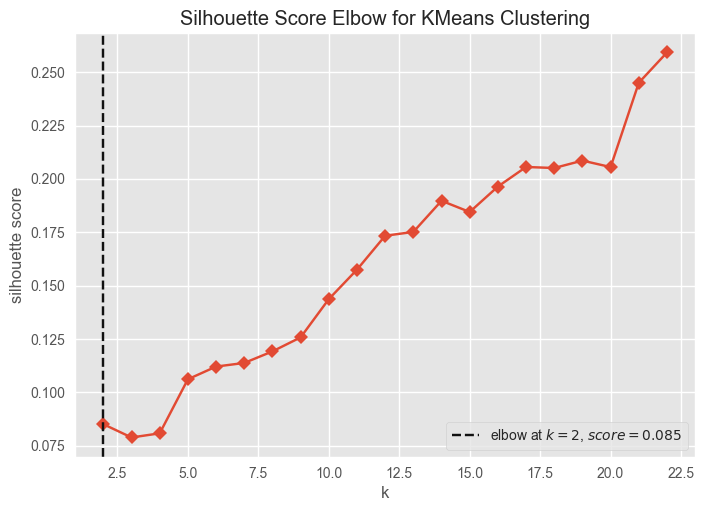

ID,Trial,P3M,P1M,Brand_Likability,Fre#visit,PPA,Spending,NPS#P3M,City,Group_size,Age,MPI#Mean,Occupation#group,NeedstateGroup,Companion#group,Segment
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,str,str,str
432464.0,1.0,1.0,1.0,0.0,1.0,30.0,30.0,5.0,"""Nha Trang""",4.0,27.0,5499.0,"""None Working""","""Socializing""","""Friends""","""Segment 1"""
126587.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Đà Nẵng""",2.0,27.0,3608.0,"""None Working""","""Working & business meeting""","""Friends""","""Segment 1"""
831421.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hồ Chí Minh""",2.0,56.0,8249.0,"""White Collar""","""Socializing""","""Friends""","""Segment 1"""
437911.0,1.0,1.0,1.0,0.0,2.0,80.0,160.0,9.0,"""Hà Nội""",3.0,42.0,6999.0,"""White Collar""","""Socializing""","""Friends""","""Segment 1"""
826239.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Đà Nẵng""",2.0,44.0,5499.0,"""Blue Collar""","""Socializing""","""Friends""","""Segment 1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
411700.0,1.0,1.0,1.0,0.0,6.0,65.0,390.0,10.0,"""Hà Nội""",2.0,41.0,10499.0,"""Self Employed - Small Business…","""Studying & Others""","""Friends""","""Segment 2"""
112818.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Hải Phòng""",5.0,33.0,6484.0,"""Blue Collar""","""Socializing""","""Friends""","""Segment 2"""
441700.0,1.0,1.0,1.0,0.0,15.0,50.0,750.0,8.0,"""Hải Phòng""",4.0,16.0,1499.0,"""None Working""","""Socializing""","""Friends""","""Segment 2"""


In [22]:
model = KMeans(random_state=RANDOM_STATE)
visualizer = KElbowVisualizer(
    model, k=(2, n_components + 1), metric="silhouette", timings=False
)
visualizer.fit(famd)
visualizer.show()

n_clusters = visualizer.elbow_value_
segments = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit_predict(
    famd
)

segmented_df = segmentation_df.hstack(
    [
        pl.Series("Segment", segments).map_elements(
            lambda x: f"Segment {x + 1}", return_dtype=str
        )
    ]
).sort("Segment")
segmented_df

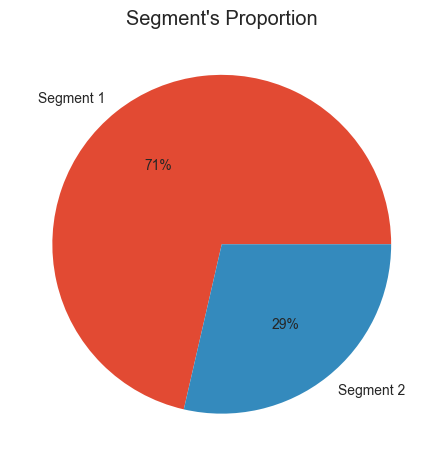

Segment,Segment Size,Trial,P3M,P1M,Brand_Likability,Fre#visit,PPA,Spending,NPS#P3M,City_Cần Thơ,City_Hà Nội,City_Hải Phòng,City_Hồ Chí Minh,City_Nha Trang,City_Đà Nẵng,Group_size,Age,MPI#Mean,Occupation#group_Blue Collar,Occupation#group_None Working,Occupation#group_Other Occupations,Occupation#group_Refuse,Occupation#group_Self Employed - Company Owner,Occupation#group_Self Employed - Small Business and Freelance,Occupation#group_White Collar,NeedstateGroup_Drinking beverages,NeedstateGroup_Meals & Snack,NeedstateGroup_Relaxing & entertainment,NeedstateGroup_Socializing,NeedstateGroup_Studying & Others,NeedstateGroup_Working & business meeting,Companion#group_Alone,Companion#group_Boyfriend / Girlfriend,Companion#group_Colleagues / Business partner,Companion#group_Family,Companion#group_Friends,Companion#group_Others
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Segment 1""",5563,0.66,0.43,0.25,0.2,1.08,12.61,54.83,3.59,0.08,0.34,0.0,0.34,0.08,0.17,3.36,32.58,6899.84,0.33,0.31,0.01,0.0,0.0,0.0,0.35,0.03,0.01,0.04,0.79,0.04,0.09,0.03,0.01,0.03,0.09,0.84,0.0
"""Segment 2""",2228,0.7,0.47,0.28,0.22,1.21,14.5,62.86,3.88,0.03,0.23,0.47,0.17,0.03,0.06,3.43,35.35,9575.48,0.13,0.08,0.0,0.0,0.05,0.61,0.12,0.02,0.0,0.03,0.81,0.02,0.11,0.02,0.01,0.02,0.07,0.88,0.0


In [23]:
segment_info = (
    segmented_df.drop("ID")
    .to_dummies(
        ["City", "Occupation#group", "NeedstateGroup", "Companion#group"]
    )
    .group_by("Segment")
    .agg(
        [
            pl.count("Segment").alias("Segment Size"),
            pl.col("*").mean().round(2),
        ]
    )
    .sort("Segment")
)

plt.pie(
    segment_info["Segment Size"],
    labels=segment_info["Segment"],
    autopct="%.0f%%",
)
plt.title("Segment's Proportion")
plt.show()
segment_info

In [ ]:
segmented_pd = segmented_df.to_pandas()
segmented_pd['Churn'] = ((segmented_pd['P3M'] > 0) & (segmented_pd['P1M'] == 0)).astype(int)

In [70]:
import warnings
warnings.filterwarnings('ignore')
leaky_cols = ["P3M", "P1M"] 
feature_cols = [
    "Brand_Likability", "Fre#visit", "PPA", "Spending", "NPS#P3M",
    "Group_size", "Age", "MPI#Mean", "City", "Occupation#group",
    "NeedstateGroup", "Companion#group"
]

for seg, seg_name in segment_names.items():
    print(f"\n=== {seg_name} ({seg}) ===")
    df_seg = segmented_pd[segmented_pd["Segment"] == seg].copy()

    X = df_seg[feature_cols].copy()
    X = pd.get_dummies(X, drop_first=True)
    y = df_seg["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(random_state=42, use_label_encoder=True, eval_metric='logloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

    feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print("Top yếu tố ảnh hưởng churn:")
    print(feat_imp.head(10))


=== Khách hàng Thử nghiệm & Giá trị thấp (Segment 1) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       908
           1       0.99      1.00      0.99       205

    accuracy                           1.00      1113
   macro avg       0.99      1.00      1.00      1113
weighted avg       1.00      1.00      1.00      1113

ROC AUC: 0.994831846996884
Top yếu tố ảnh hưởng churn:
Fre#visit                             0.819574
NPS#P3M                               0.159243
Occupation#group_White Collar         0.002104
Occupation#group_Other Occupations    0.002019
Companion#group_Family                0.001816
Occupation#group_None Working         0.001757
NeedstateGroup_Socializing            0.001648
City_Nha Trang                        0.001564
City_Hồ Chí Minh                      0.001550
Brand_Likability                      0.001469
dtype: float32

=== Khách hàng Trung Thành Cao nhất (Segment 2) ===
              precisio

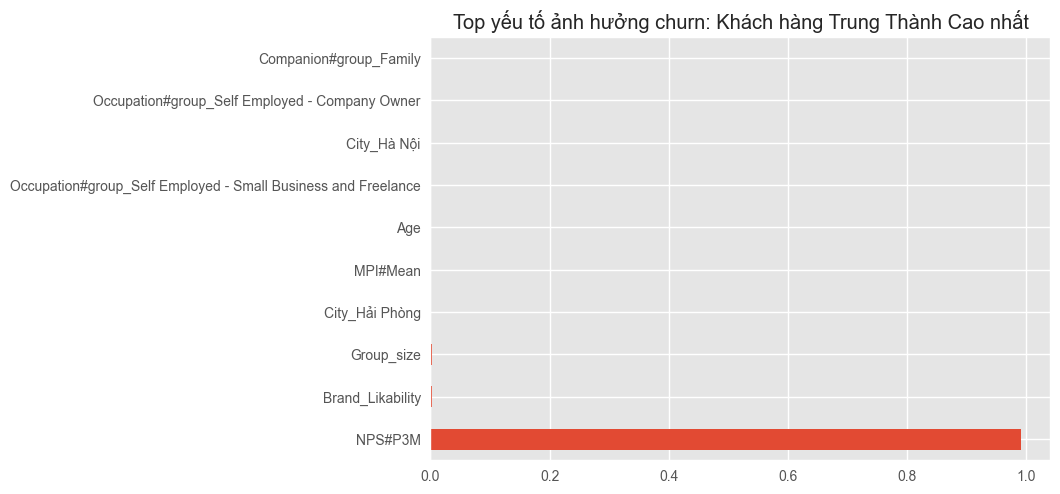

In [65]:
feat_imp.head(10).plot(kind='barh')
plt.title(f'Top yếu tố ảnh hưởng churn: {seg_name}')
plt.show()

In [50]:
theta = segment_info["Segment"].to_list()
theta.append(theta[0])

fig_perceptual = go.Figure()
for perceptual in ["Trial", "P3M", "P1M", "Brand_Likability", "NPS#P3M"]:
    p = segment_info[perceptual] / segment_info[perceptual].max()
    p = p.to_list()
    p.append(p[0])
    fig_perceptual.add_trace(
        go.Scatterpolar(
            r=p,
            theta=theta,
            name=perceptual,
        )
    )

fig_perceptual.update_layout(title=dict(text="Perceptual Factors"))
fig_perceptual.write_image("Perceptual.png")

In [51]:
fig_behavioral = go.Figure()
for behavioral in ["Fre#visit", "PPA", "Spending"]:
    b = segment_info[behavioral] / segment_info[behavioral].max()
    b = b.to_list()
    b.append(b[0])
    fig_behavioral.add_trace(
        go.Scatterpolar(
            r=b,
            theta=theta,
            name=behavioral,
        )
    )

fig_behavioral.update_layout(title=dict(text="Behavioral Factors"))
fig_behavioral.write_image("Behavioral.png")

ColumnNotFoundError: "column_2" not found

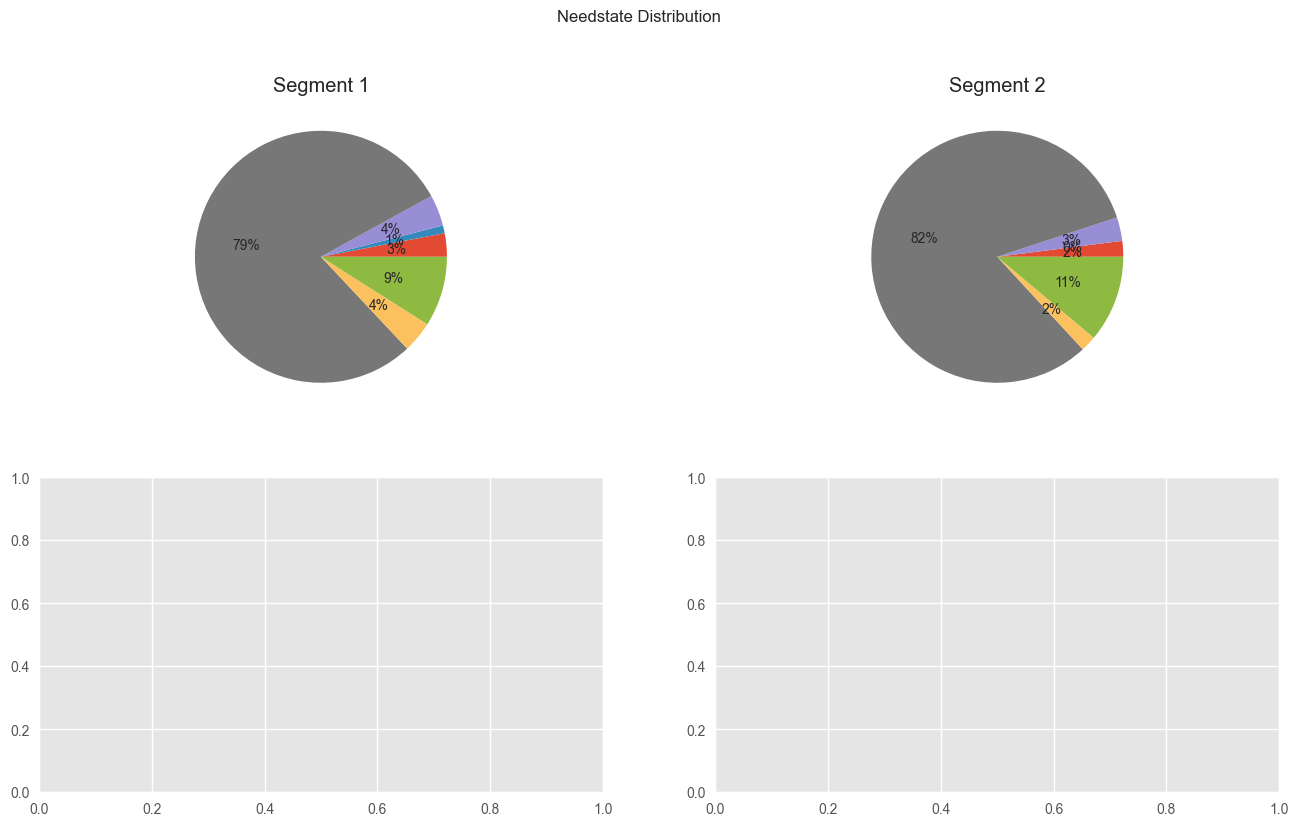

In [52]:
fig_needstate, axs_needstate = plt.subplots(2, 2, figsize=(16, 9))
fig_needstate.suptitle("Needstate Distribution")

needstate_info = (
    segment_info.select(cs.starts_with("Needstate")) * 100
).transpose(include_header=True)

for idx in range(4):
    row = idx // 2
    col = idx % 2
    axs_needstate[row][col].pie(
        needstate_info[f"column_{idx}"],
        autopct="%.0f%%",
    )
    axs_needstate[row][col].set_title(f"Segment {idx + 1}")

fig_needstate.legend(
    needstate_info["column"].to_list(),
    loc="center",
)
plt.show()


fig_com, axs_com = plt.subplots(2, 2, figsize=(16, 9))
fig_com.suptitle("Companion Group Distribution")

com_info = (segment_info.select(cs.starts_with("Companion")) * 100).transpose(
    include_header=True
)

for idx in range(4):
    row = idx // 2
    col = idx % 2
    axs_com[row][col].pie(
        com_info[f"column_{idx}"],
        autopct="%.0f%%",
    )
    axs_com[row][col].set_title(f"Segment {idx + 1}")

fig_com.legend(
    com_info["column"].to_list(),
    loc="center",
)
plt.show()


fig_city, axs_city = plt.subplots(2, 2, figsize=(16, 9))
fig_city.suptitle("City Distribution")

city_info = (segment_info.select(cs.starts_with("City")) * 100).transpose(
    include_header=True
)

for idx in range(4):
    row = idx // 2
    col = idx % 2
    axs_city[row][col].pie(
        city_info[f"column_{idx}"],
        autopct="%.0f%%",
    )
    axs_city[row][col].set_title(f"Segment {idx + 1}")

fig_city.legend(
    city_info["column"].to_list(),
    loc="center",
)
plt.show()


fig_occ, axs_occ = plt.subplots(2, 2, figsize=(16, 9))
fig_occ.suptitle("Occupation Distribution")

occ_info = (segment_info.select(cs.starts_with("Occupation")) * 100).transpose(
    include_header=True
)

for idx in range(4):
    row = idx // 2
    col = idx % 2
    axs_occ[row][col].pie(
        occ_info[f"column_{idx}"],
        autopct="%.0f%%",
    )
    axs_occ[row][col].set_title(f"Segment {idx + 1}")

fig_occ.legend(
    occ_info["column"].to_list(),
    loc="center",
)
plt.show()

Text(0.5, 1.0, 'Age distribution')

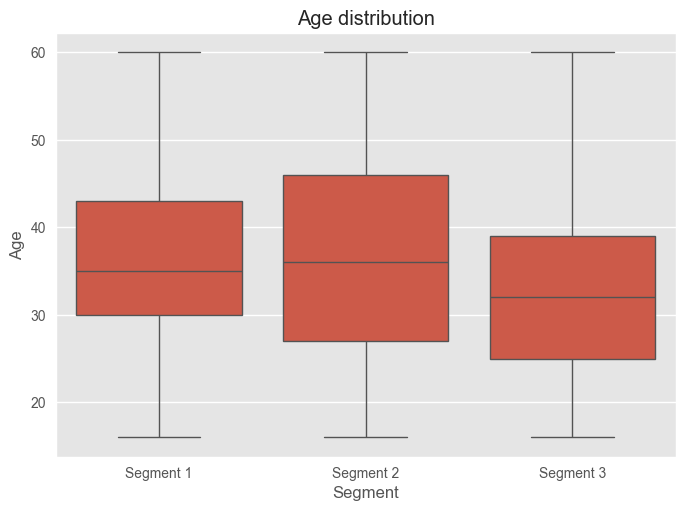

In [10]:
sns.boxplot(data=segmented_df, x="Segment", y="Age")
plt.title("Age distribution")

Text(0.5, 1.0, 'MPI distribution')

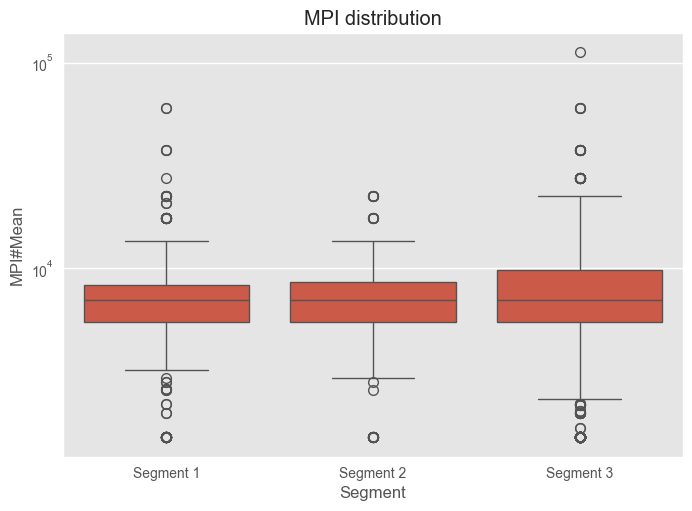

In [11]:
sns.boxplot(data=segmented_df, x="Segment", y="MPI#Mean", log_scale=True)
plt.title("MPI distribution")

Text(0.5, 1.0, 'Group size distribution')

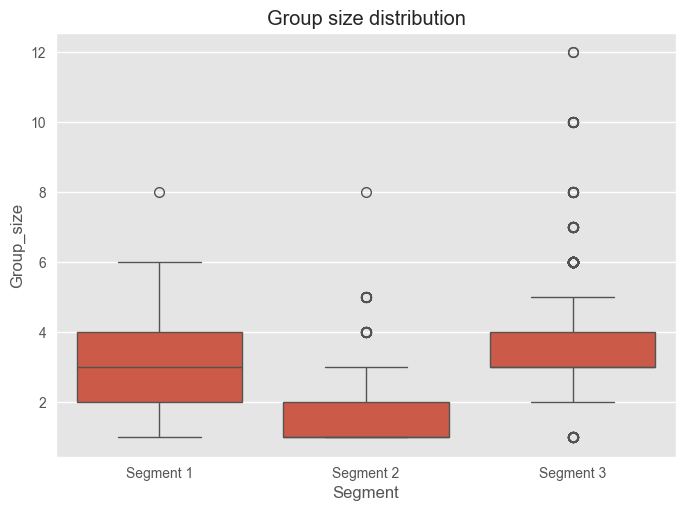

In [12]:
sns.boxplot(data=segmented_df, x="Segment", y="Group_size")
plt.title("Group size distribution")